In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

plt.style.use("ggplot")

In [2]:
fund_master = pd.read_csv("01_fund_master (1).csv")
nav = pd.read_csv("02_nav_history (1).csv")
aum = pd.read_csv("03_aum_by_fund_house (1).csv")
sip = pd.read_csv("04_monthly_sip_inflows (1).csv")
category = pd.read_csv("05_category_inflows (1).csv")
folio = pd.read_csv("06_industry_folio_count (1).csv")
performance = pd.read_csv("07_scheme_performance (1).csv")
transactions = pd.read_csv("08_investor_transactions (1).csv")
portfolio = pd.read_csv("09_portfolio_holdings (1).csv")
benchmark = pd.read_csv("10_benchmark_indices (1).csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
datasets = {
    "Fund Master": fund_master,
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print("="*40)
    print(name)
    print(df.columns.tolist())

Fund Master
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
NAV
['amfi_code', 'date', 'nav']
AUM
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
Category
['month', 'category', 'net_inflow_crore']
Folio
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
Performance
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']
Transactions
['investor_id

In [4]:
# Convert date columns

nav['date'] = pd.to_datetime(nav['date'])
aum['date'] = pd.to_datetime(aum['date'])
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])
portfolio['portfolio_date'] = pd.to_datetime(portfolio['portfolio_date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])
sip['month'] = pd.to_datetime(sip['month'])
category['month'] = pd.to_datetime(category['month'])
folio['month'] = pd.to_datetime(folio['month'])

print("Date conversion completed.")

Date conversion completed.


In [5]:
# Daily Returns

nav = nav.sort_values(['amfi_code','date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

print(nav[['amfi_code','date','nav','daily_return']].head())

nav.to_csv("daily_returns.csv",index=False)

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210


In [6]:
cagr = performance[['scheme_name',
                    'return_1yr_pct',
                    'return_3yr_pct',
                    'return_5yr_pct']]

cagr.head()

,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


In [7]:
sharpe = performance[['scheme_name','sharpe_ratio']]

sharpe = sharpe.sort_values(
    by='sharpe_ratio',
    ascending=False
)

sharpe.head(10)

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


In [8]:
sortino = performance[['scheme_name','sortino_ratio']]

sortino = sortino.sort_values(
    by='sortino_ratio',
    ascending=False
)

sortino.head(10)

,scheme_name,sortino_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,10.37
23,Kotak Liquid Fund - Regular - Growth,9.70
30,ABSL Liquid Fund - Regular - Growth,8.76
9,HDFC Short Term Debt Fund - Regular - Growth,2.79
19,Nippon India Gilt Securities Fund - Regular - ...,2.38
4,SBI Magnum Gilt Fund - Regular Plan - Growth,2.11
5,HDFC Top 100 Fund - Regular Plan - Growth,1.70
15,Nippon India Large Cap Fund - Regular - Growth,1.68
3,SBI Small Cap Fund - Direct Plan - Growth,1.67
34,Mirae Asset Large Cap Fund - Regular - Growth,1.66


In [9]:
alpha_beta = performance[[
    'scheme_name',
    'alpha',
    'beta'
]]

alpha_beta.to_csv(
    "alpha_beta.csv",
    index=False
)

alpha_beta.head()

,scheme_name,alpha,beta
0,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


In [10]:
drawdown = performance[[
    'scheme_name',
    'max_drawdown_pct'
]]

drawdown = drawdown.sort_values(
    by='max_drawdown_pct'
)

drawdown.head(10)

,scheme_name,max_drawdown_pct
6,HDFC Top 100 Fund - Direct Plan - Growth,-33.50
35,Mirae Asset Emerging Bluechip Fund - Regular -...,-33.15
26,Axis Midcap Fund - Regular - Growth,-32.38
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,-32.22
17,Nippon India Small Cap Fund - Regular - Growth,-30.87
24,Axis Bluechip Fund - Regular - Growth,-27.54
38,DSP Midcap Fund - Regular - Growth,-26.99
18,Nippon India ETF Nifty 50 BeES,-26.75
11,ICICI Pru Bluechip Fund - Direct - Growth,-26.59
10,ICICI Pru Bluechip Fund - Regular - Growth,-25.91


In [11]:
# Fund Scorecard

scorecard = performance.copy()

scorecard['score'] = (
    scorecard['return_3yr_pct'].rank(pct=True)*30 +
    scorecard['sharpe_ratio'].rank(pct=True)*25 +
    scorecard['alpha'].rank(pct=True)*20 +
    (1-scorecard['expense_ratio_pct'].rank(pct=True))*15 +
    (1-scorecard['max_drawdown_pct'].rank(pct=True))*10
)

scorecard = scorecard.sort_values("score",ascending=False)

scorecard[['scheme_name','score']].head(10)

,scheme_name,score
3,SBI Small Cap Fund - Direct Plan - Growth,72.1250
22,Kotak Flexicap Fund - Regular - Growth,70.8750
21,Kotak Emerging Equity Fund - Regular - Growth,69.8750
29,ABSL Small Cap Fund - Regular - Growth,67.6250
2,SBI Small Cap Fund - Regular Plan - Growth,63.7500
34,Mirae Asset Large Cap Fund - Regular - Growth,63.3125
9,HDFC Short Term Debt Fund - Regular - Growth,62.3750
14,ICICI Pru Liquid Fund - Regular - Growth,61.1250
12,ICICI Pru Midcap Fund - Regular - Growth,60.3750
11,ICICI Pru Bluechip Fund - Direct - Growth,59.0000


In [12]:
scorecard[['scheme_name','score']].to_csv(
    "fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved")

Fund Scorecard Saved


In [13]:
import matplotlib.pyplot as plt

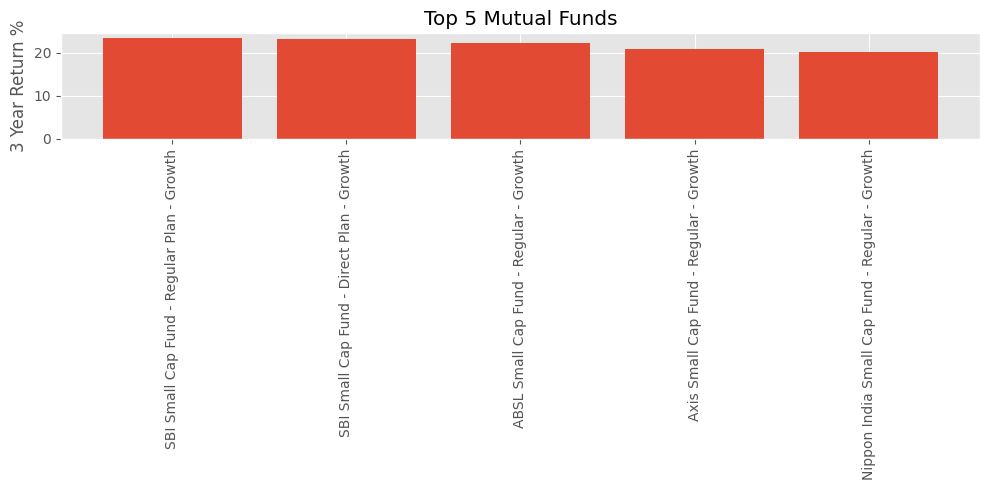

In [14]:
top5 = performance.sort_values(
    "return_3yr_pct",
    ascending=False
).head(5)

plt.figure(figsize=(10,5))

plt.bar(
    top5['scheme_name'],
    top5['return_3yr_pct']
)

plt.xticks(rotation=90)

plt.ylabel("3 Year Return %")

plt.title("Top 5 Mutual Funds")

plt.tight_layout()

plt.savefig("benchmark_comparison.png")

plt.show()

In [15]:
import os

files=[
"daily_returns.csv",
"alpha_beta.csv",
"fund_scorecard.csv",
"benchmark_comparison.png"
]

for f in files:
    print(f, os.path.exists(f))

daily_returns.csv True
alpha_beta.csv True
fund_scorecard.csv True
benchmark_comparison.png True
